# Smartphone Addiction: Exploratory Data Analysis (EDA)

Playground Series S6E8 — predicting `addicted_label` (binary) from screen-time, sleep, stress, and academic-impact features.

This notebook follows the Phase 1 checklist in `docs/2_implementation_plan.md`, revised per the Codex review in `docs/archive/4_codex_claude_review_log.md` §13: schema confirmation, class balance, per-feature signal (effect size, univariate AUC, mutual information — not raw mean-differences or Pearson correlation alone), missingness structure, categorical interactions, a corrected duplicate-row count, and train/test distribution checks including adversarial validation.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
sns.set_palette("viridis")
pd.set_option("display.max_columns", 50)

## 1. Data Loading & Schema Confirmation

In [2]:
# Dynamic path resolution: Kaggle (competition input path) vs local
if os.path.exists("/kaggle/input/playground-series-s6e8"):
    DATA_DIR = "/kaggle/input/playground-series-s6e8"
else:
    DATA_DIR = "../data"

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

TARGET = "addicted_label"
NUMERIC_FEATURES = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time",
]
CATEGORICAL_FEATURES = ["gender", "stress_level", "academic_work_impact"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"train: {train.shape}, test: {test.shape}, sample_submission: {sample_submission.shape}")
train.head()

train: (691369, 14), test: (296302, 13), sample_submission: (296302, 2)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [3]:
train.dtypes.to_frame("dtype")

,dtype
id,int64
age,float64
daily_screen_time_hours,float64
social_media_hours,float64
gaming_hours,float64
work_study_hours,float64
sleep_hours,float64
notifications_per_day,float64
app_opens_per_day,float64
weekend_screen_time,float64


**Insight:** schema matches `docs/1_instructions.md` — 12 features (9 numeric + 3 categorical), `id`, target `addicted_label`.

## 2. Target Framing

addicted_label
0    200895
1    490474
Name: count, dtype: int64
Positive rate: 0.7094


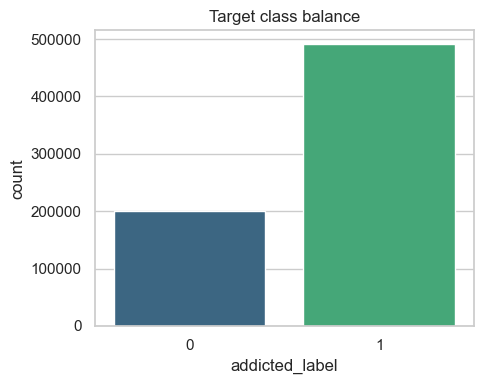

In [4]:
target_counts = train[TARGET].value_counts().sort_index()
target_rate = train[TARGET].mean()
print(target_counts)
print(f"Positive rate: {target_rate:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, hue=target_counts.index.astype(str), palette="viridis", legend=False, ax=ax)
ax.set_xlabel("addicted_label")
ax.set_ylabel("count")
ax.set_title("Target class balance")
plt.tight_layout()
plt.show()

**Insight:** positive rate is `490,474 / 691,369 = 0.7094` (negative: `200,895 / 691,369 = 0.2906`) — matches the value already used to size `docs/2_implementation_plan.md`; no correction needed.

## 3. Numeric Feature Signal: Effect Size and Univariate AUC

Raw class-mean differences are not comparable across features with different units and scales (a gap of `+3.7` means something different for `age` in years than for `notifications_per_day` in counts), and are sensitive to outliers/skew. Two scale-free diagnostics instead: **standardized effect size** (Cohen's *d*, using each feature's own pooled standard deviation) and **univariate ROC AUC** (how well the raw feature value alone ranks the target — the same metric this competition is scored on). Both computed pairwise-complete (rows where that feature is missing are dropped for that feature only).

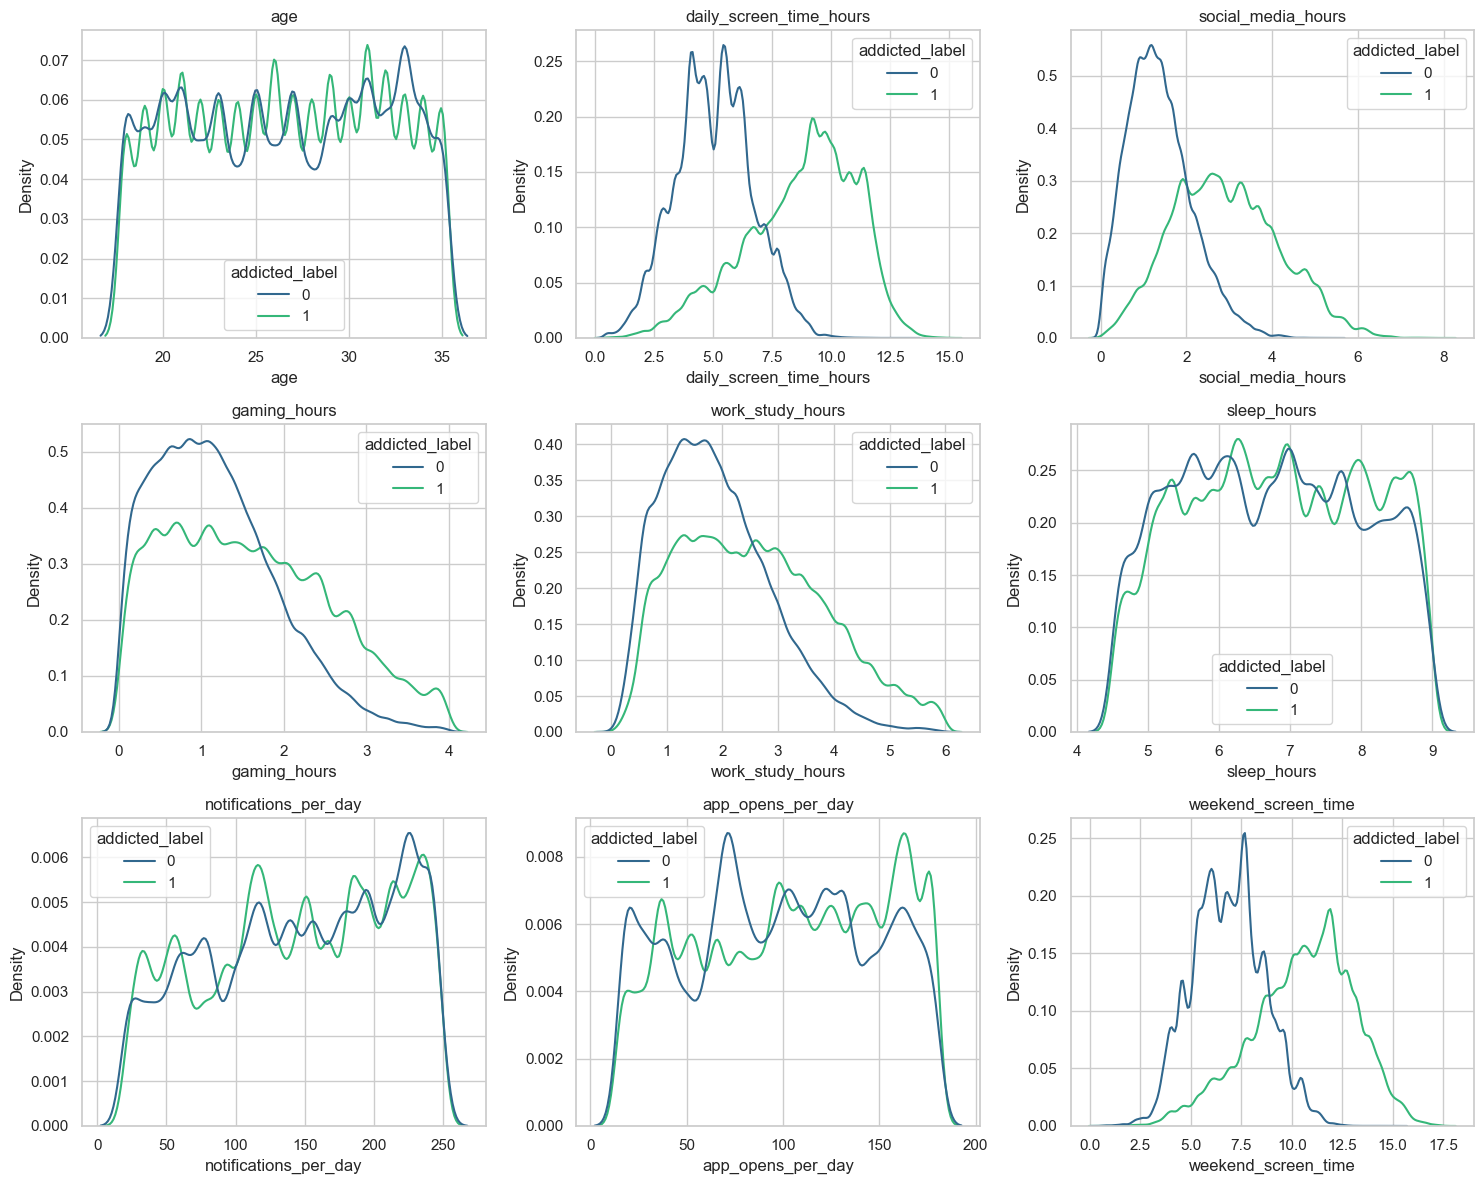

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.ravel(), NUMERIC_FEATURES):
    sns.kdeplot(data=train, x=col, hue=TARGET, common_norm=False, ax=ax, palette="viridis")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [6]:
def cohens_d(values: pd.Series, labels: pd.Series) -> float:
    """Standardized mean difference (label=1 minus label=0), pooled SD."""
    g1 = values[labels == 1]
    g0 = values[labels == 0]
    n1, n0 = len(g1), len(g0)
    pooled_var = ((n1 - 1) * g1.var() + (n0 - 1) * g0.var()) / (n1 + n0 - 2)
    return (g1.mean() - g0.mean()) / np.sqrt(pooled_var)

rows = []
for col in NUMERIC_FEATURES:
    valid = train[[col, TARGET]].dropna()
    d = cohens_d(valid[col], valid[TARGET])
    auc = roc_auc_score(valid[TARGET], valid[col])
    rows.append({
        "feature": col,
        "cohens_d": d,
        "univariate_auc": auc,
        "n_valid": len(valid),
    })
numeric_signal = pd.DataFrame(rows).sort_values("univariate_auc", key=lambda s: (s - 0.5).abs(), ascending=False)
numeric_signal

,feature,cohens_d,univariate_auc,n_valid
1,daily_screen_time_hours,1.701191,0.889550,595515
8,weekend_screen_time,1.608657,0.880988,579306
2,social_media_hours,1.385297,0.857782,557374
4,work_study_hours,0.572066,0.654880,639851
3,gaming_hours,0.461862,0.621960,564548
7,app_opens_per_day,0.140038,0.540883,610659
5,sleep_hours,0.093765,0.526953,646889
6,notifications_per_day,-0.025511,0.492145,623785
0,age,0.008904,0.502272,662440


**Insight:** univariate AUC and Cohen's *d* agree closely on ranking (both scale-free), and both disagree with the raw mean-difference table from the previous revision of this notebook: `app_opens_per_day` no longer looks like a strong feature once compared on a standardized basis — see the exact numbers in `docs/3_eda_insights.md` §3, which is the source of truth for this run's values (deliberately not restated here to avoid drift between this cell and the doc if either is re-run/edited independently).

## 4. Missingness Analysis

In [7]:
def missingness_table(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Return missing count and rate per column."""
    n = len(df)
    miss = df[cols].isna().sum()
    return pd.DataFrame({"missing_count": miss, "missing_rate": miss / n}).sort_values(
        "missing_rate", ascending=False
    )

train_missing = missingness_table(train, ALL_FEATURES)
test_missing = missingness_table(test, ALL_FEATURES)
missing_compare = train_missing[["missing_rate"]].join(
    test_missing[["missing_rate"]], lsuffix="_train", rsuffix="_test"
)
missing_compare["rate_diff"] = missing_compare["missing_rate_train"] - missing_compare["missing_rate_test"]
missing_compare.sort_values("missing_rate_train", ascending=False)

,missing_rate_train,missing_rate_test,rate_diff
social_media_hours,0.193811,0.159962,0.033849
gaming_hours,0.183435,0.200539,-0.017104
weekend_screen_time,0.162089,0.171099,-0.009011
daily_screen_time_hours,0.138644,0.110657,0.027986
app_opens_per_day,0.116739,0.086753,0.029987
notifications_per_day,0.097754,0.115494,-0.017740
stress_level,0.079766,0.066236,0.013530
work_study_hours,0.074516,0.093746,-0.019230
sleep_hours,0.064336,0.075784,-0.011448
academic_work_impact,0.063966,0.086807,-0.022841


**Insight:** per-column missingness *rates* differ between train and test by up to a few points — large relative to the binomial standard error at this sample size, so likely a deliberate generator difference rather than sampling noise. This is a difference in missingness *rate* only; Section 8 checks whether the *values themselves* (and, separately, the missingness pattern as a whole) differ between train and test.

### 4.1 Is missingness informative? Target rate by missing-vs-present

In [8]:
rows = []
for col in ALL_FEATURES:
    is_missing = train[col].isna()
    rate_missing = train.loc[is_missing, TARGET].mean()
    rate_present = train.loc[~is_missing, TARGET].mean()
    rows.append({
        "feature": col,
        "target_rate_missing": rate_missing,
        "target_rate_present": rate_present,
        "diff": rate_missing - rate_present,
    })
missingness_signal = pd.DataFrame(rows).sort_values("diff", key=np.abs, ascending=False)
missingness_signal

,feature,target_rate_missing,target_rate_present,diff
5,sleep_hours,0.713377,0.709153,0.004224
0,age,0.713402,0.709251,0.004151
7,app_opens_per_day,0.712787,0.708980,0.003807
1,daily_screen_time_hours,0.711301,0.709122,0.002178
8,weekend_screen_time,0.710654,0.709187,0.001467
3,gaming_hours,0.710505,0.709182,0.001324
4,work_study_hours,0.710645,0.709326,0.001319
6,notifications_per_day,0.710242,0.709336,0.000906
9,gender,0.708790,0.709452,-0.000662
10,stress_level,0.709001,0.709461,-0.000460


**Insight:** marginal (unconditional) target-rate differences between missing-vs-present rows are small for every column. This is evidence against a *strong marginal* missingness signal, but it does not rule out a conditional effect (missingness that matters only combined with other features) — that requires a model, not a marginal comparison. Per the Codex review (`docs/archive/4_codex_claude_review_log.md` §13.2/5.2), treat `_is_missing` indicator flags as a **low-cost OOF ablation to still try in Phase 2**, not as ruled out by this table alone.

### 4.2 Missingness co-occurrence between columns

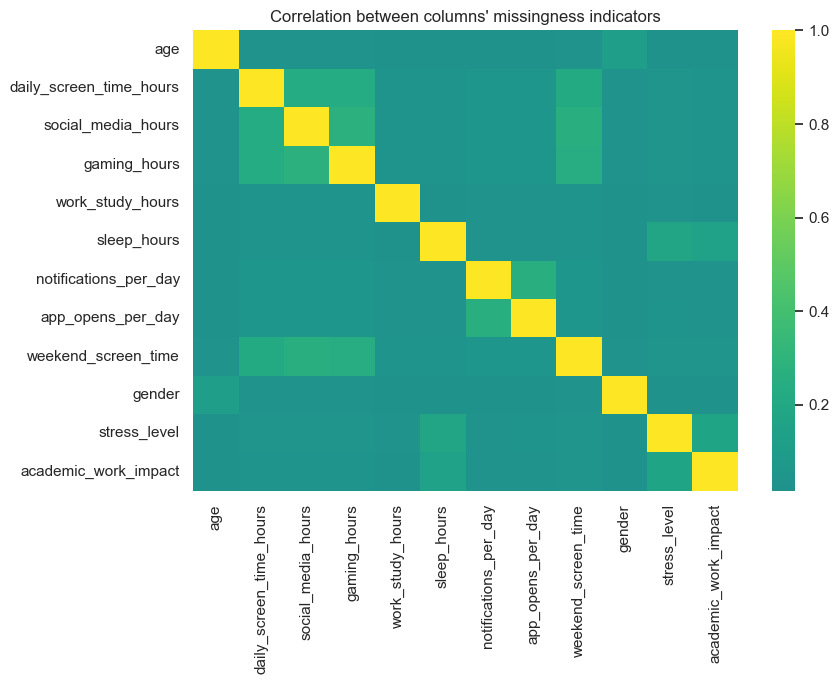

In [9]:
missing_indicator = train[ALL_FEATURES].isna().astype(int)
missing_corr = missing_indicator.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(missing_corr, cmap="viridis", center=0, annot=False, ax=ax)
ax.set_title("Correlation between columns' missingness indicators")
plt.tight_layout()
plt.show()

**Insight:** two moderate clusters, not independent per-field missingness: a screen-time/engagement block (`social_media_hours`, `gaming_hours`, `weekend_screen_time`, `daily_screen_time_hours`) and a notification/app-usage pair (`notifications_per_day`, `app_opens_per_day`). Rows that skip one screen-time question tend to skip the others. If `_is_missing` flags are added in Phase 2, a single grouped count per cluster is a reasonable first cut, alongside — not instead of — testing per-column flags, since the OOF ablation in §4.1's insight is the actual decision mechanism.

## 5. Categorical Features

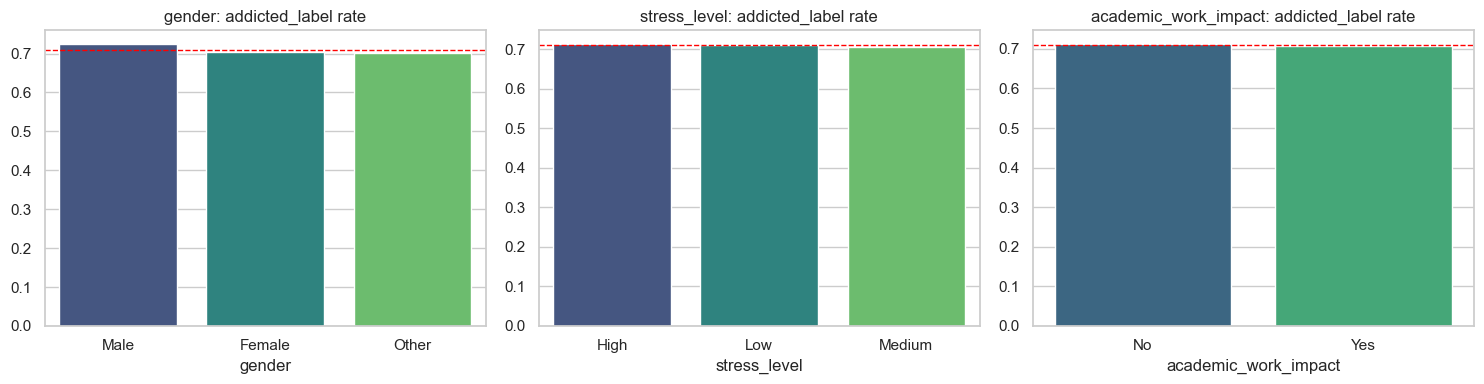

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, CATEGORICAL_FEATURES):
    rate = train.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette="viridis", legend=False, ax=ax)
    ax.set_title(f"{col}: addicted_label rate")
    ax.axhline(train[TARGET].mean(), color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [11]:
for col in CATEGORICAL_FEATURES:
    print(f"--- {col} ---")
    print(train.groupby(col)[TARGET].agg(["count", "mean"]))
    print()

--- gender ---
         count      mean
gender                  
Female  221595  0.703838
Male    223662  0.723198
Other   217078  0.701020

--- stress_level ---
               count      mean
stress_level                  
High          220873  0.711431
Low           207783  0.711160
Medium        207565  0.705663

--- academic_work_impact ---
                       count      mean
academic_work_impact                  
No                    316579  0.711029
Yes                   330566  0.707883



**Insight:** `gender` shows the clearest gap (Male above Female/Other, all ~220k rows so statistically solid despite the modest effect size). `stress_level` is **non-monotonic** (High ~= Low > Medium) — do not assume ordinal encoding for this feature by default, unlike `stress_level` in `kaggle-s6e7`; treat it as unordered native-categorical first and validate ordinal encoding as an explicit OOF experiment. Exact rates in `docs/3_eda_insights.md` §7.

## 6. Feature Signal Ranking: Pearson, Univariate AUC, and Mutual Information

Three complementary, deliberately different diagnostics — no single one is treated as authoritative (per `docs/archive/4_codex_claude_review_log.md` §13.2.3/5.1): **Pearson correlation** (linear/monotonic association, numeric features only), **univariate AUC** (Section 3, rank-based, numeric only), and **mutual information** (captures nonlinear/non-monotonic dependence, all 12 features). Mutual information needs complete data, so it is computed on a deterministic stratified sample with explicit median/mode imputation — **this imputation is local to this diagnostic only** and is not used anywhere else in the notebook or applied to `train`/`test` themselves, since Phase 2 modeling must keep any real imputation fold-safe (`docs/0_coding_standards.md`).

In [12]:
corr_with_target = (
    train[NUMERIC_FEATURES + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)
corr_with_target.to_frame("pearson_corr_with_target")

,pearson_corr_with_target
daily_screen_time_hours,0.611398
weekend_screen_time,0.589903
social_media_hours,0.532409
work_study_hours,0.251416
gaming_hours,0.205283
app_opens_per_day,0.063482
sleep_hours,0.042545
notifications_per_day,-0.011583
age,0.004043


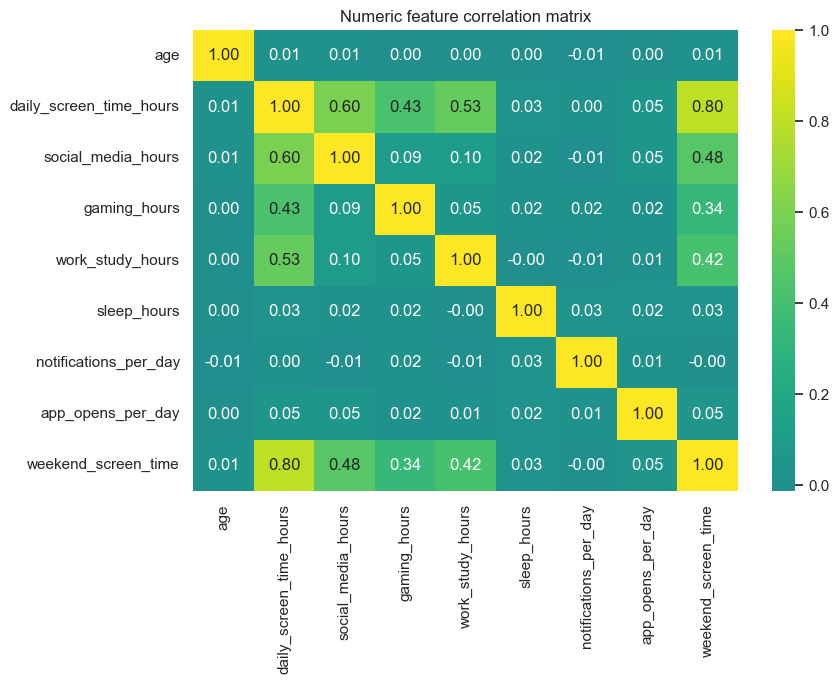

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(train[NUMERIC_FEATURES].corr(), cmap="viridis", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Numeric feature correlation matrix")
plt.tight_layout()
plt.show()

`age`, `notifications_per_day`, and `app_opens_per_day` are integer-valued (stored as `float64` only because of missing values — confirmed `(values == values.round()).all()` on the non-missing entries) with far fewer unique values (18 / 231 / 166) than a genuinely continuous feature would have over 691k rows. `mutual_info_classif`'s continuous estimator is a k-nearest-neighbor entropy estimate that assumes no value repeats — heavily tied integer-valued data biases it. Marked discrete here, with integer-safe (rounded) imputation, alongside the 3 categorical features — not treated as continuous as in the notebook's prior revision (`docs/archive/4_codex_claude_review_log.md` §15.3).

In [14]:
# Mutual information: deterministic stratified sample + explicit
# imputation, local to this diagnostic only (see markdown above).
MI_SAMPLE_SIZE = 150_000
mi_sample, _ = train_test_split(
    train,
    train_size=MI_SAMPLE_SIZE,
    stratify=train[TARGET],
    random_state=SEED,
)

DISCRETE_INTEGER_FEATURES = ["age", "notifications_per_day", "app_opens_per_day"]
CONTINUOUS_FEATURES = [c for c in NUMERIC_FEATURES if c not in DISCRETE_INTEGER_FEATURES]

mi_X = mi_sample[ALL_FEATURES].copy()
for col in CONTINUOUS_FEATURES:
    mi_X[col] = mi_X[col].fillna(mi_X[col].median())
for col in DISCRETE_INTEGER_FEATURES:
    mi_X[col] = mi_X[col].fillna(round(mi_X[col].median())).astype(int)
for col in CATEGORICAL_FEATURES:
    mi_X[col] = mi_X[col].fillna(mi_X[col].mode().iloc[0])
    mi_X[col] = mi_X[col].astype("category").cat.codes
discrete_mask = [c in CATEGORICAL_FEATURES + DISCRETE_INTEGER_FEATURES for c in ALL_FEATURES]

mi_scores = mutual_info_classif(
    mi_X[ALL_FEATURES], mi_sample[TARGET], discrete_features=discrete_mask, random_state=SEED
)
mutual_info_table = pd.Series(mi_scores, index=ALL_FEATURES).sort_values(ascending=False).to_frame("mutual_info")
mutual_info_table

,mutual_info
daily_screen_time_hours,2.230181e-01
weekend_screen_time,2.040250e-01
social_media_hours,1.576268e-01
notifications_per_day,8.569085e-02
app_opens_per_day,7.754024e-02
work_study_hours,3.903641e-02
gaming_hours,2.768427e-02
sleep_hours,1.124819e-02
age,3.522042e-03
gender,2.300329e-04


**Insight:** treat this mutual-information ranking as *exploratory*, not an authoritative feature-selection rule — it is computed on an imputed sample, and small MI values are noisy. Compare against the prior (continuous-estimator) run to see whether correcting the discrete/continuous split changes which features rank where — exact values and interpretation in `docs/3_eda_insights.md` §6.

## 7. Duplicate Rows

Corrected methodology (previous revision conflated test-internal duplicates with true cross-split matches by running `duplicated()` on a single concatenated frame — see `docs/archive/4_codex_claude_review_log.md` §13.2.1/5.4). Three numbers, computed separately: train-internal, test-internal, and true cross-split matches via an explicit inner join on the shared feature columns.

In [15]:
train_features = train.drop(columns=["id", TARGET])
test_features = test.drop(columns=["id"])

train_internal_dupes = train_features.duplicated().sum()
test_internal_dupes = test_features.duplicated().sum()

# Explicit inner join on distinct feature-rows: counts how many distinct
# row-patterns appear in both splits (robust to multiplicity/hash collisions,
# unlike a concat-then-duplicated() approach).
cross_split_matches = pd.merge(
    train_features.drop_duplicates(),
    test_features.drop_duplicates(),
    how="inner",
).shape[0]

print(f"Train-internal duplicate rows (excl. id/target): {train_internal_dupes}")
print(f"Test-internal duplicate rows (excl. id): {test_internal_dupes}")
print(f"Distinct feature-rows appearing in both train and test: {cross_split_matches}")

Train-internal duplicate rows (excl. id/target): 0
Test-internal duplicate rows (excl. id): 0
Distinct feature-rows appearing in both train and test: 2


**Insight:** all three counts are near zero relative to the dataset size — see `docs/3_eda_insights.md` §8 for the exact numbers and interpretation. This does not by itself establish there is no useful row-level leakage signal beyond exact matches; it only rules out exact duplication.

## 8. Train/Test Distribution Checks

### 8.1 Numeric Features (Kolmogorov-Smirnov)

In [16]:
drift_rows = []
for col in NUMERIC_FEATURES:
    train_vals = train[col].dropna()
    test_vals = test[col].dropna()
    stat, pval = stats.ks_2samp(train_vals, test_vals)
    drift_rows.append({"feature": col, "ks_stat": stat, "p_value": pval})
drift_table = pd.DataFrame(drift_rows).sort_values("ks_stat", ascending=False)
drift_table

,feature,ks_stat,p_value
6,notifications_per_day,0.002683,0.140034
5,sleep_hours,0.002180,0.319206
3,gaming_hours,0.002089,0.459751
7,app_opens_per_day,0.002083,0.389429
1,daily_screen_time_hours,0.001727,0.646735
8,weekend_screen_time,0.001671,0.720232
2,social_media_hours,0.001599,0.770263
0,age,0.001448,0.804106
4,work_study_hours,0.000915,0.997345


### 8.2 Categorical Features (proportions + chi-square)

In [17]:
from scipy.stats import chi2_contingency

cat_drift_rows = []
for col in CATEGORICAL_FEATURES:
    train_counts = train[col].fillna("__missing__").value_counts()
    test_counts = test[col].fillna("__missing__").value_counts()
    categories = sorted(set(train_counts.index) | set(test_counts.index))
    contingency = np.array([
        [train_counts.get(c, 0) for c in categories],
        [test_counts.get(c, 0) for c in categories],
    ])
    chi2, pval, dof, _ = chi2_contingency(contingency)
    cat_drift_rows.append({"feature": col, "chi2": chi2, "p_value": pval, "dof": dof})
cat_drift_table = pd.DataFrame(cat_drift_rows)
cat_drift_table

,feature,chi2,p_value,dof
0,gender,176.662884,4.635459e-38,3
1,stress_level,545.115509,7.955182e-118,3
2,academic_work_impact,1646.790686,0.000000e+00,2


In [18]:
for col in CATEGORICAL_FEATURES:
    train_prop = train[col].fillna("__missing__").value_counts(normalize=True)
    test_prop = test[col].fillna("__missing__").value_counts(normalize=True)
    print(f"--- {col} ---")
    print(pd.DataFrame({"train_prop": train_prop, "test_prop": test_prop}))
    print()

--- gender ---
             train_prop  test_prop
gender                            
Male           0.323506   0.321824
Female         0.320516   0.318239
Other          0.313983   0.311972
__missing__    0.041995   0.047965

--- stress_level ---
              train_prop  test_prop
stress_level                       
High            0.319472   0.322718
Low             0.300538   0.306262
Medium          0.300223   0.304784
__missing__     0.079766   0.066236

--- academic_work_impact ---
                      train_prop  test_prop
academic_work_impact                       
Yes                     0.478133   0.468083
No                      0.457902   0.445110
__missing__             0.063966   0.086807



**Insight:** univariate numeric (KS) and categorical (chi-square) checks together are still not sufficient evidence of "no drift" — both are per-feature tests and cannot detect a difference that only shows up in feature *combinations*. Section 9 runs one multivariate check (adversarial validation) for that. Exact numbers and combined interpretation in `docs/3_eda_insights.md` §8.

## 9. Adversarial Validation

A multivariate diagnostic (per `docs/archive/4_codex_claude_review_log.md` §13.2.5): train a classifier to distinguish train rows from test rows, 3-fold OOF. Interpretation is deliberately narrow — an AUC near 0.5 means this diagnostic did not detect useful split-separating signal; an AUC above 0.5 needs investigation of which features drive it; **neither result proves whether OOF CV will match the Kaggle public leaderboard**, only whether train and test are distinguishable on these features.

**On isolating what drives the signal:** `HistGradientBoostingClassifier` handles missing values natively, so a raw column with NaN already encodes both the observed value *and* the missing/not-missing pattern in one column — permuting it (as the original revision of this notebook did for permutation importance) destroys both sources at once and cannot tell them apart. A near-zero permutation importance for an explicit `_is_missing` indicator only shows the indicator is *redundant once the raw NaN-aware column is present* — it does not show the raw column's importance is about values rather than missingness (`docs/archive/4_codex_claude_review_log.md` §15.2). Instead, three separate models are trained and compared: raw features only (native NaN handling, no explicit indicators), missingness indicators only (no raw values at all), and both together — a controlled ablation, not permutation importance on one combined model.

In [19]:
adv_train = train.drop(columns=["id", TARGET]).copy()
adv_test = test.drop(columns=["id"]).copy()
adv_train["__is_test__"] = 0
adv_test["__is_test__"] = 1
adv_data = pd.concat([adv_train, adv_test], ignore_index=True)

for col in CATEGORICAL_FEATURES:
    adv_data[col] = adv_data[col].astype("category")
for col in ALL_FEATURES:
    adv_data[f"{col}_is_missing"] = adv_data[col].isna().astype(int)

RAW_COLS = ALL_FEATURES
MISSING_COLS = [f"{col}_is_missing" for col in ALL_FEATURES]
y_adv = adv_data["__is_test__"]

def run_adversarial_cv(feature_cols: list[str]) -> float:
    """3-fold OOF AUC for a classifier distinguishing train vs. test
    rows, restricted to the given feature columns."""
    X_subset = adv_data[feature_cols]
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    oof = np.zeros(len(X_subset))
    for tr_idx, val_idx in skf.split(X_subset, y_adv):
        model = HistGradientBoostingClassifier(
            random_state=SEED, max_iter=150, categorical_features="from_dtype"
        )
        model.fit(X_subset.iloc[tr_idx], y_adv.iloc[tr_idx])
        oof[val_idx] = model.predict_proba(X_subset.iloc[val_idx])[:, 1]
    return roc_auc_score(y_adv, oof)

adv_results = {
    "A_raw_features_only": run_adversarial_cv(RAW_COLS),
    "B_missingness_indicators_only": run_adversarial_cv(MISSING_COLS),
    "C_raw_plus_indicators": run_adversarial_cv(RAW_COLS + MISSING_COLS),
}
for name, auc in adv_results.items():
    print(f"{name:32s} OOF AUC = {auc:.4f}")

A_raw_features_only              OOF AUC = 0.5651
B_missingness_indicators_only    OOF AUC = 0.5654
C_raw_plus_indicators            OOF AUC = 0.5651


**Insight:** compare A vs. B vs. C directly rather than inferring from a single combined model's permutation importance. If B (indicators only) is close to 0.5, the missingness *pattern* alone carries little split-separating signal — consistent with, but not proof of, the signal being about feature values. If B is meaningfully above 0.5, missingness pattern alone is doing real work, and A's importance cannot be assumed to be purely about values (native NaN handling means A already has access to the same missingness information B does). Exact numbers and the resulting conclusion — properly hedged, not overstated — in `docs/3_eda_insights.md` §9.

### 9.1 Which Raw Features Matter Most (Experiment C)

In [20]:
from sklearn.inspection import permutation_importance

X_adv_c = adv_data[RAW_COLS + MISSING_COLS]
adv_tr_idx, adv_val_idx = train_test_split(
    np.arange(len(X_adv_c)), test_size=0.2, stratify=y_adv, random_state=SEED
)
adv_model = HistGradientBoostingClassifier(
    random_state=SEED, max_iter=150, categorical_features="from_dtype"
)
adv_model.fit(X_adv_c.iloc[adv_tr_idx], y_adv.iloc[adv_tr_idx])

PERM_SAMPLE_SIZE = 50_000
perm_sample_idx, _ = train_test_split(
    adv_val_idx,
    train_size=min(PERM_SAMPLE_SIZE, len(adv_val_idx)),
    stratify=y_adv.iloc[adv_val_idx],
    random_state=SEED,
)
perm_result = permutation_importance(
    adv_model,
    X_adv_c.iloc[perm_sample_idx],
    y_adv.iloc[perm_sample_idx],
    scoring="roc_auc",
    n_repeats=5,
    random_state=SEED,
)
perm_importance = pd.DataFrame({
    "feature": RAW_COLS + MISSING_COLS,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
perm_importance.head(10)

,feature,importance_mean,importance_std
7,app_opens_per_day,0.015656,0.001381
2,social_media_hours,0.011227,0.001335
1,daily_screen_time_hours,0.007402,0.001324
6,notifications_per_day,0.007293,0.001197
3,gaming_hours,0.005694,0.000949
11,academic_work_impact,0.005472,0.000861
4,work_study_hours,0.005203,0.000635
0,age,0.004767,0.000623
10,stress_level,0.003077,0.000540
8,weekend_screen_time,0.002439,0.000910


**Insight:** per §9's framing, this ranks which *raw* columns contribute most within the combined model (Experiment C) — useful for knowing where to look, but (per the note above Experiment A/B/C) not on its own a clean value-vs-missingness attribution. That attribution comes from comparing A and B directly, not from this table. Exact numbers in `docs/3_eda_insights.md` §9 — copied from this notebook's actual saved cell output, not a separately-run script (see `docs/archive/4_codex_claude_review_log.md` §15.4 on why that distinction matters: HistGradientBoostingClassifier was observed to give slightly different importances across separate process runs with the same `random_state`, so only this notebook's own executed output is the source of truth).

## 10. Next Moves

Phase 2 (`docs/2_implementation_plan.md`) priority order — see `docs/3_eda_insights.md` §10 for the version kept in sync with this run's actual numbers:

1. Prioritize numeric features by the univariate-AUC/Cohen's-*d* ranking (Section 3), cross-checked against mutual information (Section 6) for any feature that ranks much higher there — a sign of nonlinear signal the other two diagnostics would miss.
2. Keep `gender` and `academic_work_impact` as native categorical.
3. Treat `stress_level` as unordered native-categorical by default; validate ordinal encoding as an explicit OOF experiment (non-monotonic target rate).
4. Try `_is_missing` indicator flags as an OOF ablation in Phase 2 — not ruled out by the marginal analysis in Section 4.1, just not shown to help by it either.
5. Take the adversarial-validation result (Section 9) as input to how much to trust local OOF CV as a leaderboard proxy — not as grounds by itself to skip or add drift correction. The controlled A/B/C ablation found raw values alone and missingness indicators alone each independently reach ~the same OOF AUC as the combined model — the signal's value-vs-missingness attribution is genuinely inconclusive, not resolved in either direction.